# Proyecto RAG — Libro para la Conducción en Chile (Cap. 1)

**Grupo:** 2
**Integrantes:** Alexis Contreras , Jacqueline Diaz, Gisselle Encalada

Documento a utilizar: *Libro para la Conducción en Chile* (CONASET, 2024) — Capítulo 1: *Los siniestros de tránsito*.

**Pipeline:** ingesta → chunking justificado → embeddings → Qdrant Cloud → retrieval → re-ranking (LLM) → respuesta con fuentes.

## 0.1 · Entorno: credenciales y constantes

In [1]:
# Entorno: credenciales, modelos y constantes del proyecto
import os
import warnings
from dotenv import load_dotenv

warnings.filterwarnings("ignore")
load_dotenv()

# --- Modelos (mismos del curso) ---
EMBED_MODEL = "text-embedding-3-large"   # Matryoshka: dims reducibles sin reentrenar
EMBED_DIMS = 256                          # mismas dims en index y query
GEN_MODEL = "gpt-5.4-mini"               # generación RAG, respuestas
FAST_MODEL = "gpt-5.4-nano"              # scoring de re-ranking (barato, alto volumen)

# --- Vector store: Qdrant Cloud ---
COLLECTION = "proyecto_rag_conaset_cap1"  # nombre de tu colección (única para este proyecto)
USE_QDRANT = bool(os.getenv("QDRANT_URL"))

assert os.getenv("OPENAI_API_KEY"), "Falta OPENAI_API_KEY en .env"
assert USE_QDRANT, "Falta QDRANT_URL en .env — revisa tu archivo .env"
assert os.getenv("QDRANT_API_KEY"), "Falta QDRANT_API_KEY en .env"

print(f"OK · embeddings={EMBED_MODEL}/{EMBED_DIMS}d · gen={GEN_MODEL} · fast={FAST_MODEL}")
print(f"Qdrant URL: {os.getenv('QDRANT_URL')}")
print(f"Colección: {COLLECTION}")

OK · embeddings=text-embedding-3-large/256d · gen=gpt-5.4-mini · fast=gpt-5.4-nano
Qdrant URL: https://6e4a7203-1ae5-4553-b5f7-7bf879f8382d.sa-east-1-0.aws.cloud.qdrant.io:6333
Colección: proyecto_rag_conaset_cap1


> **GPT-5.x son _reasoning models_:** el knob de control es **`reasoning_effort`** (`none`/`low`/`medium`/`high`/`xhigh`). Usamos 3 tiers: **`gpt-5.5`** (calidad) · **`gpt-5.4-mini`** (default) · **`gpt-5.4-nano`** (bulk barato). Embeddings sin cambio: `text-embedding-3-large` (256d).

## 0.2 · Probar conexión a Qdrant Cloud

Antes de seguir, confirmamos que el cluster responde.

In [2]:
from qdrant_client import QdrantClient

client = QdrantClient(url=os.getenv("QDRANT_URL"), api_key=os.getenv("QDRANT_API_KEY"))
print("Conexión OK ·", client.get_collections())

Conexión OK · collections=[CollectionDescription(name='proyecto_rag_conaset_cap1')]


## 1 · Cargar el documento

Leemos el `.md` como texto plano y lo envolvemos en un `Document` de LangChain (con metadata de la fuente). Esto es lo que después consumen los splitters y el vector store.

In [3]:
from pathlib import Path
from langchain_core.documents import Document

DOC_PATH = Path("data/cap1_siniestros_transito.md")

texto = DOC_PATH.read_text(encoding="utf-8")

doc = Document(
    page_content=texto,
    metadata={
        "fuente": "Libro para la Conducción en Chile - CONASET (2024)",
        "capitulo": "1 - Los siniestros de tránsito",
        "archivo": DOC_PATH.name,
    },
)

print(f"Documento cargado · {len(texto)} caracteres · {len(texto.split())} palabras aprox. · ~{len(texto)//4:,} tokens aprox.")
print("Metadata:", doc.metadata)
print("\n--- Primeras 300 caracteres ---")
print(doc.page_content[:300])

Documento cargado · 10013 caracteres · 1605 palabras aprox. · ~2,503 tokens aprox.
Metadata: {'fuente': 'Libro para la Conducción en Chile - CONASET (2024)', 'capitulo': '1 - Los siniestros de tránsito', 'archivo': 'cap1_siniestros_transito.md'}

--- Primeras 300 caracteres ---
LIBRO PARA LA CONDUCCIÓN EN CHILE
Fuente: Comisión Nacional de Seguridad de Tránsito (CONASET), Chile, julio 2024.
Material de acceso público: https://mejoresconductores.conaset.cl

CAPÍTULO 1: LOS SINIESTROS DE TRÁNSITO

## Los siniestros de tránsito

Antes de comenzar, debemos saber que es un erro


## 2 · Chunking justificado

**Estrategia elegida: split por estructura (headers `##`) + sub-chunking por tamaño.**

El documento tiene 3 secciones marcadas (`Los siniestros de tránsito`, `Estadísticas de siniestros en Chile`, `Sistema Seguro`). En vez de cortar a ciegas cada N caracteres, primero dividimos por esas secciones — así cada chunk hereda en su metadata a qué sección pertenece, y podemos citar la fuente con precisión (ej. *"Sección: Sistema Seguro"*).

Como algunas secciones son largas (ej. Estadísticas, con varias listas y cifras), aplicamos un **sub-chunking** dentro de cada sección con `RecursiveCharacterTextSplitter`. Probamos **2 configuraciones** para justificar el tamaño final:
- **Config A:** `chunk_size=400`, `overlap=60`
- **Config B:** `chunk_size=800`, `overlap=120`

Chequeamos cuál preserva mejor unidades como la lista de los *"4 principios del Sistema Seguro"* (no debería quedar cortada a la mitad).

In [4]:
#pip install langchain-text-splitters

In [5]:
from langchain_text_splitters import MarkdownHeaderTextSplitter, RecursiveCharacterTextSplitter

# Paso 1: split por headers de Markdown (nivel ##)
headers_a_dividir = [("##", "seccion")]
md_splitter = MarkdownHeaderTextSplitter(headers_to_split_on=headers_a_dividir, strip_headers=False)
secciones = md_splitter.split_text(doc.page_content)

print(f"Secciones detectadas: {len(secciones)}")
for s in secciones:
    print(" -", s.metadata.get("seccion", "(sin header)"), f"· {len(s.page_content)} caracteres")

Secciones detectadas: 4
 - (sin header) · 221 caracteres
 - Los siniestros de tránsito · 4575 caracteres
 - Estadísticas de siniestros en Chile · 2576 caracteres
 - Sistema Seguro · 2666 caracteres


In [6]:
def sub_chunkear(secciones, chunk_size, overlap):
    """Aplica RecursiveCharacterTextSplitter dentro de cada sección y conserva metadata (fuente + sección)."""
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size, chunk_overlap=overlap,
        separators=["\n\n", "\n", ". ", " ", ""],
    )
    chunks = []
    for sec in secciones:
        sub_docs = splitter.create_documents(
            [sec.page_content],
            metadatas=[{**doc.metadata, **sec.metadata}],
        )
        chunks.extend(sub_docs)
    return chunks

chunks_a = sub_chunkear(secciones, chunk_size=400, overlap=60)
chunks_b = sub_chunkear(secciones, chunk_size=800, overlap=120)

print(f"Config A (400/60)  → {len(chunks_a)} chunks")
print(f"Config B (800/120) → {len(chunks_b)} chunks")

Config A (400/60)  → 38 chunks
Config B (800/120) → 16 chunks


In [7]:
# Comparación: ¿la lista de los 4 principios del Sistema Seguro queda completa o cortada?
def buscar_principios(chunks, config_nombre):
    print(f"--- {config_nombre} ---")
    for i, c in enumerate(chunks):
        if "Errar es humano" in c.page_content:
            completos = sum(p in c.page_content for p in ["1.", "2.", "3.", "4."])
            print(f"Chunk {i} · sección={c.metadata.get('seccion')} · {len(c.page_content)} chars · principios detectados: {completos}/4")

buscar_principios(chunks_a, "Config A (400/60)")
buscar_principios(chunks_b, "Config B (800/120)")

--- Config A (400/60) ---
Chunk 35 · sección=Sistema Seguro · 304 chars · principios detectados: 2/4
--- Config B (800/120) ---
Chunk 15 · sección=Sistema Seguro · 716 chars · principios detectados: 4/4


**Decisión:** nos quedamos con la config que mantenga los 4 principios en un mismo chunk (evita fragmentar una idea que se responde como conjunto). Ajusta la celda de abajo según lo que veas arriba antes de seguir.

In [8]:
# Config final elegida (ajustar tras ver el resultado de arriba)
chunks = chunks_b  # <-- cambia a chunks_a si esa resulta mejor
print(f"Chunks finales: {len(chunks)}")

Chunks finales: 16


**Nota — sobre el índice del chunk vs. el total de chunks:**

En el resultado de arriba puede parecer confuso ver "16 chunks" en un lado y "Chunk 15" en otro, pero es lo mismo, visto de dos formas distintas:
- El **total de chunks** (16) se cuenta de forma normal: 1, 2, 3… 16.
- El **índice del chunk** dentro de la lista empieza en **0** (convención estándar en Python). Por eso el último chunk de una lista de 16 elementos tiene índice **15** (0, 1, 2, … 15 → son 16 posiciones en total).

Es decir: "Chunk 15" y "el chunk número 16" son el mismo chunk — el último. No hay ninguna inconsistencia entre

## 3 · Embeddings + índice en Qdrant Cloud

Embeddeamos los chunks con `text-embedding-3-large` (256 dims) y los subimos a una colección en **Qdrant Cloud**. Usamos `distance=COSINE` (estándar del curso) y `force_recreate` para que esta celda sea **idempotente** — puedes re-ejecutarla sin duplicar vectores.

In [9]:
#pip install langchain-openai

In [10]:
from langchain_openai import OpenAIEmbeddings
from qdrant_client.models import Distance, VectorParams
from langchain_qdrant import QdrantVectorStore

embeddings = OpenAIEmbeddings(model=EMBED_MODEL, dimensions=EMBED_DIMS)

# Contrato de la colección: COSINE + 256 dims (debe ser igual al indexar y al consultar)
client.recreate_collection(
    collection_name=COLLECTION,
    vectors_config=VectorParams(size=EMBED_DIMS, distance=Distance.COSINE),
)

vector_store = QdrantVectorStore(client=client, collection_name=COLLECTION, embedding=embeddings)
vector_store.add_documents(chunks)

print(f"Índice listo · {len(chunks)} chunks subidos a Qdrant/{COLLECTION} (COSINE, {EMBED_DIMS}d)")

Índice listo · 16 chunks subidos a Qdrant/proyecto_rag_conaset_cap1 (COSINE, 256d)


**Verificación:** cuántos vectores hay en la colección y cómo luce un registro de ejemplo (id + payload + texto) — esto es lo que pide el criterio 2 de la rúbrica.

In [11]:
info = client.get_collection(COLLECTION)
print(f"Vectores en la colección: {info.points_count}")

# Traemos un registro de ejemplo (id + payload + texto) directo del cliente de Qdrant
ejemplo = client.scroll(collection_name=COLLECTION, limit=1, with_payload=True)[0][0]
print("\n--- Registro de ejemplo ---")
print("id:", ejemplo.id)
print("payload (metadata):", {k: v for k, v in ejemplo.payload.items() if k != "page_content"})
print("texto:", ejemplo.payload.get("page_content", "")[:200], "...")

Vectores en la colección: 16

--- Registro de ejemplo ---
id: 08072442-bf53-418d-a42c-dc83870fa12f
payload (metadata): {'metadata': {'fuente': 'Libro para la Conducción en Chile - CONASET (2024)', 'capitulo': '1 - Los siniestros de tránsito', 'archivo': 'cap1_siniestros_transito.md', 'seccion': 'Los siniestros de tránsito'}}
texto: Si este dinero fuera invertido en educación, vivienda, salud y/o ayudas sociales, imagina el beneficio que representaría para nuestra sociedad. Si sacas la cuenta, cada persona paga una media de poco  ...


Evidencia 

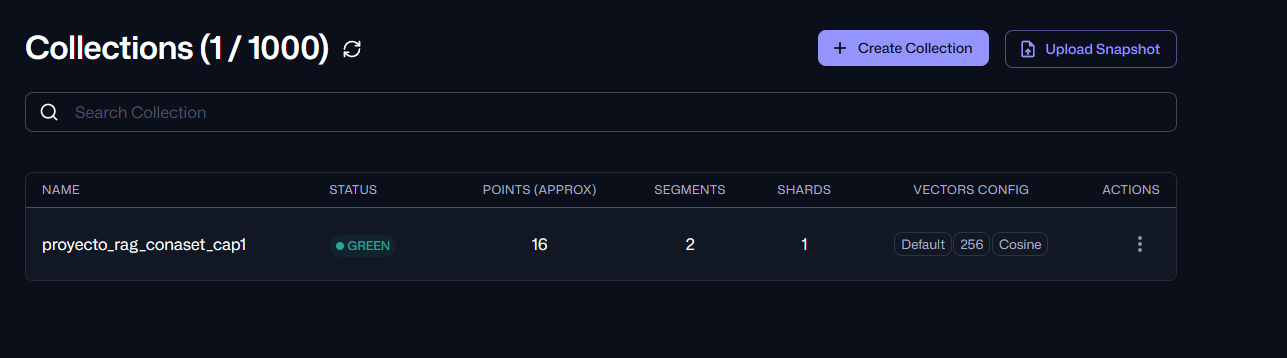

## 4 · RAG básico con fuentes

Pipeline: **pregunta → similarity search (top-k) → prompt con contexto → respuesta citando la fuente**. El LLM debe responder **solo** con lo recuperado — si no está en el contexto, debe decirlo.

In [12]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

TOP_K = 4  # cuántos chunks recuperar por pregunta

def formatear_contexto(docs) -> str:
    """Une los chunks recuperados con su sección, para poder citarlos."""
    return "\n\n".join(
        f"[Sección: {d.metadata.get('seccion', '?')}] {d.page_content}" for d in docs
    )

answer_prompt = ChatPromptTemplate.from_messages([
    ("system", "Responde la pregunta USANDO SOLO el contexto entregado. "
               "Si la respuesta no está en el contexto, dilo explícitamente, no inventes. "
               "Cita la sección de la que proviene cada dato entre [corchetes]."),
    ("human", "CONTEXTO:\n{contexto}\n\nPREGUNTA: {pregunta}"),
])

generador = ChatOpenAI(model=GEN_MODEL, reasoning_effort="low")
rag_basico = (answer_prompt | generador | StrOutputParser())

def responder(pregunta: str) -> str:
    """RAG básico: retrieve top-k -> formatear contexto -> generar con fuentes."""
    docs = vector_store.similarity_search(pregunta, k=TOP_K)
    contexto = formatear_contexto(docs)
    return rag_basico.invoke({"contexto": contexto, "pregunta": pregunta})

**Demo con 3 preguntas** (mínimo que pide la rúbrica) — 2 que sí están en el capítulo, y 1 que NO está, para comprobar que el sistema no alucina.

In [13]:
preguntas_demo = [
    "¿Cuántos siniestros de tránsito se registran anualmente en Chile y cuántas personas fallecen?",
    "¿Qué es el enfoque de Sistema Seguro y cuáles son sus principios fundamentales?",
    "¿Cuál es la velocidad máxima permitida en autopistas en Chile?",  # no está en el cap. 1 -> test anti-alucinación
]

for p in preguntas_demo:
    print(f"PREGUNTA: {p}")
    print(f"RESPUESTA: {responder(p)}")
    print("-" * 80)

PREGUNTA: ¿Cuántos siniestros de tránsito se registran anualmente en Chile y cuántas personas fallecen?
RESPUESTA: Anualmente en Chile se registran **más de 82.000 siniestros** y fallecen **aproximadamente 1.600 personas**. [Sección: Estadísticas de siniestros en Chile]
--------------------------------------------------------------------------------
PREGUNTA: ¿Qué es el enfoque de Sistema Seguro y cuáles son sus principios fundamentales?
RESPUESTA: El enfoque de **Sistema Seguro** es un cambio de paradigma que parte de la idea de que los seres humanos cometen errores y que la mayoría de los siniestros ocurren por una equivocación; por eso, en vez de corregir solo los errores humanos, busca **abordar el riesgo inherente a la circulación** mediante el diseño de un sistema completo que **apoye y guíe el comportamiento humano**. Además, el sistema se gestiona para que sus componentes interactúen de forma que ayuden a actuar con seguridad y, si ocurre un siniestro, las fuerzas del impacto n

## 5 · Re-ranking LLM-as-judge + threshold

**Por qué:** la similitud coseno trae lo que se *parece* a la pregunta, no necesariamente lo que la *responde*. El patrón **retrieve → re-rank → filtrar → generar**:

1. Recuperamos un top-k amplio (aquí acotado a lo que hay en el corpus, ya que es chico).
2. Un LLM (`FAST_MODEL`, barato) puntúa la relevancia real de cada pasaje (0.0 a 1.0).
3. Ordenamos de mayor a menor relevancia.
4. Filtramos por un **threshold**: solo generamos con los que pasan.

In [14]:
from pydantic import BaseModel, Field

class Relevancia(BaseModel):
    """Score de relevancia de un pasaje respecto de la pregunta."""
    score: float = Field(description="Relevancia de 0.0 (irrelevante) a 1.0 (responde directamente).")

rerank_prompt = ChatPromptTemplate.from_messages([
    ("system", "Eres un evaluador de relevancia para un sistema RAG. "
               "¿Qué tan relevante es el PASAJE para responder la PREGUNTA? "
               "Devuelve un número de 0.0 a 1.0. Penaliza pasajes que compartan tema pero no "
               "contengan el dato que responde la pregunta."),
    ("human", "PREGUNTA: {pregunta}\n\nPASAJE: {pasaje}"),
])

juez = ChatOpenAI(model=FAST_MODEL, reasoning_effort="none")
scorer = (rerank_prompt | juez.with_structured_output(Relevancia))

TOP_K_AMPLIO = 20   # se acota solo por lo disponible en el corpus (tienes 16 chunks)
THRESHOLD = 0.5     # umbral de relevancia; ajustable según lo que veas abajo

print(f"Config: top_k_amplio={TOP_K_AMPLIO} · threshold={THRESHOLD}")

Config: top_k_amplio=20 · threshold=0.5


In [15]:
import pandas as pd

def rerank_y_filtrar(pregunta: str, k: int = TOP_K_AMPLIO, threshold: float = THRESHOLD):
    """Retrieve amplio -> score LLM por pasaje -> ordenar desc -> filtrar por threshold."""
    candidatos = vector_store.similarity_search(pregunta, k=k)
    scores = [scorer.invoke({"pregunta": pregunta, "pasaje": d.page_content}).score for d in candidatos]
    rankeados = sorted(zip(candidatos, scores), key=lambda x: x[1], reverse=True)
    sobrevivientes = [(d, s) for d, s in rankeados if s >= threshold]
    return rankeados, sobrevivientes

pregunta_test = "¿Qué es el enfoque de Sistema Seguro y cuáles son sus principios fundamentales?"
rankeados, sobrevivientes = rerank_y_filtrar(pregunta_test)

pd.DataFrame([
    {
        "relevancia": round(s, 2),
        "pasa": "✔" if s >= THRESHOLD else "✘",
        "seccion": d.metadata.get("seccion", "?"),
        "chunk": d.page_content[:70] + "...",
    }
    for d, s in rankeados
])

,relevancia,pasa,seccion,chunk
0,0.98,✔,Sistema Seguro,Principios fundamentales y no transables del S...
1,0.78,✔,Sistema Seguro,Esto supone un cambio de paradigma en que los ...
2,0.78,✔,Sistema Seguro,"Es por esto que desde el año 2017, la nueva Po..."
3,0.20,✘,Sistema Seguro,## Sistema Seguro \nDesde la primera Política...
4,0.12,✘,Los siniestros de tránsito,"Si los siniestros de tránsito fueran ""accident..."
5,0.10,✘,Los siniestros de tránsito,La conducción de un vehículo implica responsab...
6,0.10,✘,Los siniestros de tránsito,## Los siniestros de tránsito \nAntes de come...
7,0.05,✘,?,LIBRO PARA LA CONDUCCIÓN EN CHILE\nFuente: Com...
8,0.05,✘,Los siniestros de tránsito,"En Chile, al igual que en el resto del mundo, ..."
9,0.05,✘,Los siniestros de tránsito,Nota: La mayoría de las muertes producidas por...


**Generar solo con los sobrevivientes** (los que pasaron el threshold), citando su sección.

In [16]:
def responder_rerank(pregunta: str, k: int = TOP_K_AMPLIO, threshold: float = THRESHOLD) -> str:
    """Pipeline completo: retrieve -> rerank LLM -> threshold -> generar solo con sobrevivientes."""
    _, sobrevivientes = rerank_y_filtrar(pregunta, k, threshold)
    if not sobrevivientes:
        return "Ningún pasaje recuperado superó el umbral de relevancia para esta pregunta."
    contexto = formatear_contexto([d for d, _ in sobrevivientes])
    return rag_basico.invoke({"contexto": contexto, "pregunta": pregunta})

print(responder_rerank(pregunta_test))

El **enfoque de Sistema Seguro** es un cambio de paradigma que reconoce que los seres humanos cometemos errores y que la mayoría de los siniestros ocurren por una equivocación; por eso, en vez de corregir solo el error humano, se enfoca en **abordar el riesgo inherente a la circulación** mediante el diseño de un sistema completo que apoye y guíe el comportamiento humano. Además, busca que, si ocurre un siniestro, las fuerzas del impacto no excedan los límites que el cuerpo humano puede resistir antes de que se produzcan lesiones graves o la muerte. [Sección: Sistema Seguro]

Sus **principios fundamentales y no transables** son:  
1. **Los seres humanos cometemos errores**, y estos pueden derivar en un siniestro de tránsito (“Errar es humano”). [Sección: Sistema Seguro]  
2. **El cuerpo humano tiene una capacidad limitada** para soportar las fuerzas de un impacto antes de que ocurra daño. [Sección: Sistema Seguro]  
3. **Existe responsabilidad compartida** entre quienes diseñan, constru

In [17]:
#Prueba 2
import pandas as pd

def rerank_y_filtrar(pregunta: str, k: int = TOP_K_AMPLIO, threshold: float = THRESHOLD):
    """Retrieve amplio -> score LLM por pasaje -> ordenar desc -> filtrar por threshold."""
    candidatos = vector_store.similarity_search(pregunta, k=k)
    scores = [scorer.invoke({"pregunta": pregunta, "pasaje": d.page_content}).score for d in candidatos]
    rankeados = sorted(zip(candidatos, scores), key=lambda x: x[1], reverse=True)
    sobrevivientes = [(d, s) for d, s in rankeados if s >= threshold]
    return rankeados, sobrevivientes

pregunta_test = "¿Cuántos siniestros de tránsito se registran anualmente en Chile y cuántas personas fallecen?"
rankeados, sobrevivientes = rerank_y_filtrar(pregunta_test)

pd.DataFrame([
    {
        "relevancia": round(s, 2),
        "pasa": "✔" if s >= THRESHOLD else "✘",
        "seccion": d.metadata.get("seccion", "?"),
        "chunk": d.page_content[:70] + "...",
    }
    for d, s in rankeados
])

,relevancia,pasa,seccion,chunk
0,1.00,✔,Estadísticas de siniestros en Chile,## Estadísticas de siniestros en Chile \nAnua...
1,0.45,✘,Estadísticas de siniestros en Chile,También en vías urbanas se produce la mayor ca...
2,0.25,✘,Los siniestros de tránsito,La conducción de un vehículo implica responsab...
3,0.15,✘,Los siniestros de tránsito,"En Chile, al igual que en el resto del mundo, ..."
4,0.10,✘,Los siniestros de tránsito,Nota: La mayoría de las muertes producidas por...
5,0.10,✘,Los siniestros de tránsito,## Los siniestros de tránsito \nAntes de come...
6,0.10,✘,Sistema Seguro,## Sistema Seguro \nDesde la primera Política...
7,0.10,✘,Estadísticas de siniestros en Chile,"Finalmente, se debe agregar que cerca del 79% ..."
8,0.10,✘,?,LIBRO PARA LA CONDUCCIÓN EN CHILE\nFuente: Com...
9,0.10,✘,Los siniestros de tránsito,"Si este dinero fuera invertido en educación, v..."


In [18]:
def responder_rerank(pregunta: str, k: int = TOP_K_AMPLIO, threshold: float = THRESHOLD) -> str:
    """Pipeline completo: retrieve -> rerank LLM -> threshold -> generar solo con sobrevivientes."""
    _, sobrevivientes = rerank_y_filtrar(pregunta, k, threshold)
    if not sobrevivientes:
        return "Ningún pasaje recuperado superó el umbral de relevancia para esta pregunta."
    contexto = formatear_contexto([d for d, _ in sobrevivientes])
    return rag_basico.invoke({"contexto": contexto, "pregunta": pregunta})

print(responder_rerank(pregunta_test))

En Chile se registran **más de 82.000 siniestros al año** y fallecen **aproximadamente 1.600 personas** como consecuencia de ellos. [Sección: Estadísticas de siniestros en Chile]


## 6 · Mini-eval comparativa: básico vs re-ranked

4 preguntas propias con su **respuesta esperada (gold)**, mezclando: factuales simples, una que junta datos de dos secciones (multi-hop), y una **sin respuesta** en el documento (para verificar que ninguno de los dos alucina).

In [19]:
eval_set = [
    {
        "pregunta": "¿Cuántos siniestros anuales se registran en Chile y cuántas personas fallecen?",
        "tipo": "factual",
        "gold": "Más de 82.000 siniestros al año; fallecen aproximadamente 1.600 personas.",
    },
    {
        "pregunta": "¿Cuáles son los 4 principios fundamentales del Sistema Seguro?",
        "tipo": "factual",
        "gold": "1) Errar es humano, 2) el cuerpo humano tiene capacidad limitada ante impactos, "
                "3) responsabilidad compartida entre quienes diseñan/usan el sistema, "
                "4) todos los componentes deben estar fortalecidos y respaldarse entre sí.",
    },
    {
        "pregunta": "¿Por qué se dice que un siniestro de tránsito no es un simple 'accidente', y qué tiene que ver esto con el enfoque de Sistema Seguro?",
        "tipo": "multi-hop",
        "gold": "Porque 'accidente' implica algo azaroso e impredecible, pero los siniestros están "
                "asociados a condiciones y conductas estudiables (lluvia, noche, alcohol). El enfoque "
                "Sistema Seguro conecta con esto porque asume que los seres humanos cometen errores "
                "previsibles, y en vez de solo corregir esos errores, diseña el sistema completo "
                "para que esos errores no terminen en muerte o lesión grave.",
    },
    {
        "pregunta": "¿Qué documentación se necesita para renovar la licencia de conducir clase B?",
        "tipo": "sin respuesta",
        "gold": "No está en el Capítulo 1 (ese trámite se describe en otro capítulo del libro).",
    },
]
print(f"{len(eval_set)} preguntas de evaluación listas.")

4 preguntas de evaluación listas.


In [20]:
# resultados = []
# for item in eval_set:
#     resp_basico = responder(item["pregunta"])
#     resp_rerank = responder_rerank(item["pregunta"])
#     resultados.append({
#         "pregunta": item["pregunta"],
#         "tipo": item["tipo"],
#         "gold": item["gold"],
#         "respuesta_basico": resp_basico,
#         "respuesta_rerank": resp_rerank,
#     })

# df_eval = pd.DataFrame(resultados)
# df_eval[["pregunta", "tipo", "respuesta_basico", "respuesta_rerank"]]
# #tiempo de procesamiento 1min23s

In [21]:
import time

resultados = []
for item in eval_set:
    t0 = time.time()
    resp_basico = responder(item["pregunta"])
    t_basico = time.time() - t0

    t0 = time.time()
    resp_rerank = responder_rerank(item["pregunta"])
    t_rerank = time.time() - t0

    resultados.append({
        "pregunta": item["pregunta"],
        "tipo": item["tipo"],
        "gold": item["gold"],
        "respuesta_basico": resp_basico,
        "tiempo_basico_seg": round(t_basico, 1),
        "respuesta_rerank": resp_rerank,
        "tiempo_rerank_seg": round(t_rerank, 1),
    })

df_eval = pd.DataFrame(resultados)

# Tabla resumen: solo tiempos y tipo (visual, para comparar velocidad de un vistazo)
df_eval[["pregunta", "tipo", "tiempo_basico_seg", "tiempo_rerank_seg"]]

,pregunta,tipo,tiempo_basico_seg,tiempo_rerank_seg
0,¿Cuántos siniestros anuales se registran en Ch...,factual,1.5,18.1
1,¿Cuáles son los 4 principios fundamentales del...,factual,2.6,20.3
2,¿Por qué se dice que un siniestro de tránsito ...,multi-hop,3.3,18.3
3,¿Qué documentación se necesita para renovar la...,sin respuesta,1.8,16.4


In [22]:
for r in resultados:
    print(f"PREGUNTA ({r['tipo']}): {r['pregunta']}")
    print(f"GOLD: {r['gold']}")
    print(f"\n[BÁSICO · {r['tiempo_basico_seg']}s]\n{r['respuesta_basico']}")
    print(f"\n[RE-RANKED · {r['tiempo_rerank_seg']}s]\n{r['respuesta_rerank']}")
    print("=" * 100)

PREGUNTA (factual): ¿Cuántos siniestros anuales se registran en Chile y cuántas personas fallecen?
GOLD: Más de 82.000 siniestros al año; fallecen aproximadamente 1.600 personas.

[BÁSICO · 1.5s]
En Chile se registran **más de 82.000 siniestros anuales** y fallecen **aproximadamente 1.600 personas** al año. [Sección: Estadísticas de siniestros en Chile]

[RE-RANKED · 18.1s]
En Chile se registran **más de 82.000 siniestros al año** y fallecen **aproximadamente 1.600 personas** [Sección: Estadísticas de siniestros en Chile].
PREGUNTA (factual): ¿Cuáles son los 4 principios fundamentales del Sistema Seguro?
GOLD: 1) Errar es humano, 2) el cuerpo humano tiene capacidad limitada ante impactos, 3) responsabilidad compartida entre quienes diseñan/usan el sistema, 4) todos los componentes deben estar fortalecidos y respaldarse entre sí.

[BÁSICO · 2.6s]
Los 4 principios fundamentales y no transables del Sistema Seguro son:  

1. Los seres humanos cometemos errores, y esos errores pueden deriva

**Conclusión:**

Se evaluaron 4 preguntas, comparando la respuesta obtenida contra la 
respuesta esperada (gold), para verificar que el LLM no inventara información.

En las primeras 2 preguntas factuales (dato disponible directamente en el 
documento), la respuesta del básico(respuesta por similarity) y del re-ranked (a partir de la similaridad reorderna solo con los valores que si sobrevivieron) fueron muy similares 
entre sí y cercanas al gold — la diferencia principal fue el tiempo de 
ejecución, notablemente mayor en el re-ranked.

En la pregunta 3 (multi-hop), la respuesta requería conectar información 
de dos secciones distintas del documento (por qué un siniestro no es un 
"accidente" + el enfoque de Sistema Seguro). Tampoco hubo diferencias 
relevantes entre el básico y el re-ranked frente al gold; nuevamente se 
notó el tiempo de ejecución excesivo en el re-ranked.

En la pregunta 4 (sin respuesta en el documento), se buscaba validar que 
el sistema no alucinara. El básico evitó inventar porque el LLM generador 
decidió no hacerlo por sí mismo; el re-ranked, en cambio, descartó todos 
los chunks por baja relevancia y ni siquiera intentó generar una 
respuesta — una barrera mecánica adicional contra la alucinación, que no 
depende solo de las instrucciones del prompt.

## BONUS 1 · Filtrado por metadata

Cada chunk ya trae `seccion` en su metadata (del split por headers del Paso 1 - cargar el documento). Con eso podemos **restringir la búsqueda a una sección específica antes de embeddear la similitud** — útil cuando el usuario ya sabe de qué parte del documento quiere preguntar, o para acotar el retrieval en documentos más grandes con muchas secciones.

Qdrant soporta esto de forma nativa con un `Filter` sobre el payload, sin tener que traer todo y filtrar después en Python.

In [23]:
from qdrant_client.models import PayloadSchemaType

# Qdrant Cloud exige un índice de payload para poder filtrar por un campo.
# Sin esto, filter=... falla con 400 Bad Request. Se crea una sola vez;
# si ya existe, Qdrant lo ignora sin error.
client.create_payload_index(
    collection_name=COLLECTION,
    field_name="metadata.seccion",
    field_schema=PayloadSchemaType.KEYWORD,
)
print("Índice de payload creado para 'metadata.seccion'")

Índice de payload creado para 'metadata.seccion'


In [24]:
from qdrant_client.models import Filter, FieldCondition, MatchValue

def responder_con_filtro(pregunta: str, seccion: str, k: int = TOP_K) -> str:
    """RAG básico, pero acotado a una sección específica vía filtro de metadata en Qdrant."""
    filtro = Filter(
        must=[FieldCondition(key="metadata.seccion", match=MatchValue(value=seccion))]
    )
    docs = vector_store.similarity_search(pregunta, k=k, filter=filtro)
    if not docs:
        return f"No se encontraron chunks en la sección '{seccion}' para esta pregunta."
    contexto = formatear_contexto(docs)
    return rag_basico.invoke({"contexto": contexto, "pregunta": pregunta})

# Demo: la misma pregunta, pero forzada a buscar solo en "Estadísticas" vs solo en "Sistema Seguro"
pregunta_ambigua = "¿qué dice el documento sobre los principios o los números clave?"

print("--- Filtrado a 'Estadísticas de siniestros en Chile' ---")
print(responder_con_filtro(pregunta_ambigua, "Estadísticas de siniestros en Chile"))
print("\n--- Filtrado a 'Sistema Seguro' ---")
print(responder_con_filtro(pregunta_ambigua, "Sistema Seguro"))

--- Filtrado a 'Estadísticas de siniestros en Chile' ---
El documento destaca estos **números clave** y **factores principales** sobre los siniestros de tránsito en Chile:

- **Más de 82.000 siniestros al año** y **aproximadamente 1.600 fallecidos**; eso equivale a **entre 4 y 5 muertes diarias** en las vías públicas. [Sección: Estadísticas de siniestros en Chile]
- En promedio, **450 personas atropelladas** fallecen. [Sección: Estadísticas de siniestros en Chile]
- La **mayor parte de las personas fallecidas** ocurre en **vías interurbanas o no urbanas**, aunque la **mayor cantidad de siniestros** se produce en **zonas urbanas**: cerca de **80%**. [Sección: Estadísticas de siniestros en Chile]
- De esos siniestros urbanos, la mayoría ocurre en **cruces o intersecciones**. [Sección: Estadísticas de siniestros en Chile]
- En zonas no urbanas ocurre solo cerca de **20%** de los siniestros. [Sección: Estadísticas de siniestros en Chile]
- La **falla humana** está presente en **más del 90%

**Observación:** con la misma pregunta ambigua, el filtro por metadata fuerza al sistema a responder **solo** con lo que hay en la sección indicada, en vez de dejar que la similitud decida libremente. Esto es útil, por ejemplo, para una UI donde el usuario elige un capítulo/sección antes de preguntar.

## BONUS 2 · Query rewriting

Las preguntas reales de un usuario suelen ser cortas, vagas o con pronombres — malas para similarity search. Antes de buscar, le pedimos a `FAST_MODEL` que **reescriba la pregunta** agregando términos específicos del dominio (tránsito, siniestros, seguridad vial), sin cambiar su intención.

In [25]:
rewrite_prompt = ChatPromptTemplate.from_messages([
    ("system", "Reescribe la pregunta del usuario para que sea más específica y efectiva "
               "para buscar en un documento sobre siniestros de tránsito y seguridad vial en Chile. "
               "Agrega términos relevantes del dominio si faltan. No cambies la intención original. "
               "Devuelve SOLO la pregunta reescrita, sin explicaciones."),
    ("human", "{pregunta}"),
])

reescritor = ChatOpenAI(model=FAST_MODEL, reasoning_effort="low")
rewrite_chain = (rewrite_prompt | reescritor | StrOutputParser())

def responder_con_rewrite(pregunta: str, k: int = TOP_K) -> str:
    """Reescribe la query con el LLM antes de buscar, y genera con el RAG básico."""
    pregunta_reescrita = rewrite_chain.invoke({"pregunta": pregunta})
    docs = vector_store.similarity_search(pregunta_reescrita, k=k)
    contexto = formatear_contexto(docs)
    respuesta = rag_basico.invoke({"contexto": contexto, "pregunta": pregunta_reescrita})
    return pregunta_reescrita, respuesta

# Demo con una query deliberadamente floja/coloquial
query_floja = "oye y por qué la gente se muere tanto manejando en la noche o cuando toma"

reescrita, respuesta = responder_con_rewrite(query_floja)
print(f"QUERY ORIGINAL:  {query_floja}")
print(f"QUERY REESCRITA: {reescrita}")
print(f"\nRESPUESTA:\n{respuesta}")

QUERY ORIGINAL:  oye y por qué la gente se muere tanto manejando en la noche o cuando toma
QUERY REESCRITA: ¿Según los informes y estadísticas sobre siniestros de tránsito y seguridad vial en Chile, por qué aumentan las muertes en accidentes de tránsito durante la conducción nocturna y/o cuando los conductores han consumido alcohol u otras sustancias?

RESPUESTA:
Según el contexto, **no se entrega una explicación causal detallada específica** de por qué aumentan las muertes durante la conducción nocturna o cuando se ha consumido alcohol u otras sustancias; **solo se señala que esos patrones no serían compatibles con que los siniestros fueran “accidentales” o puramente eventuales** [Sección: Los siniestros de tránsito].

Lo que sí indica el texto es que la mayor incidencia en la ocurrencia de siniestros se relaciona con **la imprudencia de quien conduce, el consumo de alcohol al conducir y la desobediencia a las señales del tránsito** [Sección: Estadísticas de siniestros en Chile]. Adem

**Observación:** con la query original (coloquial, sin términos técnicos) el similarity search puede fallar en traer el chunk correcto. Al reescribirla con vocabulario del documento (ej. "siniestros nocturnos", "alcohol en la conducción"), el retrieval mejora sin que el usuario tenga que saber cómo "hablarle" al sistema.

# BONUS 3 · Multi-query / HyDE

Las preguntas de un usuario real suelen ser vagas o coloquiales — malas para similarity search. Dos técnicas para mejorarlas **antes** de recuperar (ambas con `FAST_MODEL`, barato):

- **HyDE** (*Hypothetical Document Embeddings*): el LLM inventa una respuesta hipotética plausible; embeddeamos ESA respuesta en vez de la pregunta. Intuición: una respuesta se parece más a los chunks reales que una pregunta corta.
- **Multi-query**: el LLM genera 3 variantes de la misma pregunta (distinto ángulo/vocabulario cada una); buscamos con cada una y juntamos los chunks únicos recuperados.

In [26]:
# --- HyDE ---
hyde_prompt = ChatPromptTemplate.from_template(
    "Escribe 2-3 frases que respondan de forma plausible a esta pregunta, "
    "como si fueran un extracto de un manual de conducción y seguridad vial. "
    "No agregues introducciones, solo el contenido hipotético.\n\nPregunta: {pregunta}"
)
hyde_chain = (hyde_prompt | ChatOpenAI(model=FAST_MODEL, reasoning_effort="low") | StrOutputParser())

def responder_hyde(pregunta: str, k: int = TOP_K) -> tuple[str, str]:
    """HyDE: genera respuesta hipotética -> la usa como query para buscar -> genera respuesta real."""
    hipotetica = hyde_chain.invoke({"pregunta": pregunta})
    docs = vector_store.similarity_search(hipotetica, k=k)
    contexto = formatear_contexto(docs)
    respuesta = rag_basico.invoke({"contexto": contexto, "pregunta": pregunta})
    return hipotetica, respuesta

In [27]:
# --- Multi-query ---
class Variantes(BaseModel):
    """3 reformulaciones de la misma pregunta, con distinto vocabulario/ángulo."""
    queries: list[str] = Field(description="3 variantes de la pregunta original.")

multiquery_prompt = ChatPromptTemplate.from_template(
    "Genera 3 reformulaciones distintas de esta pregunta sobre seguridad vial y "
    "tránsito en Chile, cada una con vocabulario o ángulo diferente, manteniendo "
    "la intención original.\n\nPregunta: {pregunta}"
)
multiquery_chain = (
    multiquery_prompt
    | ChatOpenAI(model=FAST_MODEL, reasoning_effort="low").with_structured_output(Variantes)
)

def responder_multiquery(pregunta: str, k: int = TOP_K) -> tuple[list[str], str]:
    """Multi-query: genera variantes -> busca con cada una -> une chunks únicos -> genera."""
    variantes = multiquery_chain.invoke({"pregunta": pregunta}).queries
    vistos, docs_unicos = set(), []
    for q in [pregunta] + variantes:
        for d in vector_store.similarity_search(q, k=k):
            if d.page_content not in vistos:
                vistos.add(d.page_content)
                docs_unicos.append(d)
    contexto = formatear_contexto(docs_unicos)
    respuesta = rag_basico.invoke({"contexto": contexto, "pregunta": pregunta})
    return variantes, respuesta

**Demo comparativa** con una pregunta deliberadamente vaga/coloquial, contra el RAG básico (sin ninguna de las dos técnicas).

In [28]:
query_vaga = "oye y por qué la gente se muere tanto manejando en la noche o cuando toma"

print("--- BÁSICO (sin HyDE ni multi-query) ---")
print(responder(query_vaga))

print("\n--- HyDE ---")
hipotetica, resp_hyde = responder_hyde(query_vaga)
print(f"Respuesta hipotética usada como query: {hipotetica}")
print(f"\nRespuesta final: {resp_hyde}")

print("\n--- Multi-query ---")
variantes, resp_multi = responder_multiquery(query_vaga)
print(f"Variantes generadas: {variantes}")
print(f"\nRespuesta final: {resp_multi}")

--- BÁSICO (sin HyDE ni multi-query) ---
Porque, según el contexto, hay **mayor siniestralidad durante la noche y la madrugada o en situaciones de escaso flujo vehicular** [Sección: Estadísticas de siniestros en Chile]. Además, **el consumo de alcohol al conducir** y **la imprudencia de quien conduce** son factores de mayor incidencia en la وقوعencia de siniestros [Sección: Estadísticas de siniestros en Chile].

El texto también señala que los siniestros de tránsito **no son simples “accidentes”**, porque su ocurrencia no depende solo del tiempo al volante, sino que se relaciona con esas condiciones y conductas [Sección: Los siniestros de tránsito].

--- HyDE ---
Respuesta hipotética usada como query: Evita manejar de noche si es posible, porque la visibilidad disminuye, tardas más en detectar obstáculos y aumenta el riesgo de colisiones. No conduzcas después de consumir alcohol o con fatiga: las reacciones se vuelven más lentas y el juicio para calcular distancias se deteriora notable

**Observación:** con una query coloquial, tanto HyDE como multi-query intentan "traducir" la pregunta al vocabulario del documento (siniestros, Sistema Seguro, factores de riesgo) antes de buscar. En un corpus tan chico (16 chunks) la ganancia puede ser sutil, pero en documentos más grandes o con vocabulario más técnico, esta diferencia se nota mucho más en la calidad del retrieval.